### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

SEED = 42

### Load data

In [3]:
stat_df_clahe = pd.read_csv("../data/ml_features/features_stat_clahe.csv")
lbp_df_clahe = pd.read_csv("../data/ml_features/features_lbp_clahe.csv")
hog_df_clahe = pd.read_csv("../data/ml_features/features_hog_clahe.csv")
stat_df_no_clahe = pd.read_csv("../data/ml_features/features_stat_no_clahe.csv")
lbp_df_no_clahe = pd.read_csv("../data/ml_features/features_lbp_no_clahe.csv")
hog_df_no_clahe = pd.read_csv("../data/ml_features/features_hog_no_clahe.csv")

### Feature combinations

In [4]:
id_cols = ["image_name", "class"]

df_stat_clahe = stat_df_clahe.copy()
df_lbp_clahe = lbp_df_clahe.copy()
df_hog_clahe = hog_df_clahe.copy()
df_stat_lbp_clahe = df_stat_clahe.merge(df_lbp_clahe, on=id_cols)
df_stat_hog_clahe = df_stat_clahe.merge(df_hog_clahe, on=id_cols)
df_lbp_hog_clahe = df_lbp_clahe.merge(df_hog_clahe, on=id_cols)
df_stat_lbp_hog_clahe = (df_stat_clahe.merge(df_lbp_clahe, on=id_cols).merge(df_hog_clahe, on=id_cols))

df_stat_no_clahe = stat_df_no_clahe.copy()
df_lbp_no_clahe = lbp_df_no_clahe.copy()
df_hog_no_clahe = hog_df_no_clahe.copy()
df_stat_lbp_no_clahe = df_stat_no_clahe.merge(df_lbp_no_clahe, on=id_cols)
df_stat_hog_no_clahe = df_stat_no_clahe.merge(df_hog_no_clahe, on=id_cols)
df_lbp_hog_no_clahe = df_lbp_no_clahe.merge(df_hog_no_clahe, on=id_cols)
df_stat_lbp_hog_no_clahe = (df_stat_no_clahe.merge(df_lbp_no_clahe, on=id_cols).merge(df_hog_no_clahe, on=id_cols))

datasets = {
    "STAT_CLAHE": df_stat_clahe,
    "LBP_CLAHE": df_lbp_clahe,
    "HOG_CLAHE": df_hog_clahe,
    "STAT_LBP_CLAHE": df_stat_lbp_clahe,
    "STAT_HOG_CLAHE": df_stat_hog_clahe,
    "LBP_HOG_CLAHE": df_lbp_hog_clahe,
    "STAT_LBP_HOG_CLAHE": df_stat_lbp_hog_clahe,
    "STAT_NO_CLAHE": df_stat_no_clahe,
    "LBP_NO_CLAHE": df_lbp_no_clahe,
    "HOG_NO_CLAHE": df_hog_no_clahe,
    "STAT_LBP_NO_CLAHE": df_stat_lbp_no_clahe,
    "STAT_HOG_NO_CLAHE": df_stat_hog_no_clahe,
    "LBP_HOG_NO_CLAHE": df_lbp_hog_no_clahe,
    "STAT_LBP_HOG_NO_CLAHE": df_stat_lbp_hog_no_clahe,
}


### UTILS

In [5]:
def prepare_dataset(df):
    df = df.copy()

    X = df.drop(columns=["image_name", "class"])
    y = df["class"]

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.2,
        random_state=SEED,
        stratify=y_encoded
    )

    return X_train, X_test, y_train, y_test, label_encoder

In [6]:
def load_model_and_test_data(model_name):
    if model_name.split("_")[0] == "rf":
        model_path = "random_forest"
    elif model_name.split("_")[0] == "svm":
        model_path = "support_vector_machine"
    elif model_name.split("_")[0] == "xgb":
        model_path = "xgboost"
    elif model_name.split("_")[0] == "knn":
        model_path = "k_nearest_neighbors"
    model = joblib.load(f"../models/{model_path}/{model_name}.pkl")
    df = datasets[model_name.split("_", 1)[1].upper()]
    X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df)
    return model, X_test, y_test, label_encoder

In [7]:
def plot_confusion_matrix(model_name, normalize=None):
    model, X_test, y_test, label_encoder = load_model_and_test_data(model_name)

    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(
        y_test,
        y_pred,
        normalize=normalize
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        values_format=".2f" if normalize else "d"
    )

    title = f"Confusion Matrix - {model_name}"
    if normalize:
        title = f"Normalized Confusion Matrix - {model_name}"

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [8]:
def print_classification_report(model_name):
    model, X_test, y_test, label_encoder = load_model_and_test_data(model_name)
    
    y_pred = model.predict(X_test)

    print(f"\nRapport de classification pour le modèle {model_name}:\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

In [9]:
def plot_feature_importance(model_name, top_n=10):

    model, X_test, y_test, label_encoder = load_model_and_test_data(model_name)
    X_train, _, _, _, _ = prepare_dataset(datasets[model_name.split("_", 1)[1].upper()])

    importances = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    })

    importances = importances.sort_values(
        "importance",
        ascending=False
    ).head(top_n)

    plt.figure(figsize=(8, 8))
    plt.barh(
        importances["feature"][::-1],
        importances["importance"][::-1]
    )

    plt.title(f"Top {top_n} Feature Importances - {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

### SUPPORT VECTOR MACHINE (SVM)

In [27]:
def train_svm(X_train, y_train):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            # kernel="rbf",
            # C=1.0,
            # gamma="scale",
            class_weight="balanced",
            random_state=SEED
        ))
    ])

    model.fit(X_train, y_train)

    return model

# datasets_test = {
#     "STAT_LBP_HOG_CLAHE": df_stat_lbp_hog_clahe,
# }

MODEL_DIR = "../models/support_vector_machine"
os.makedirs(MODEL_DIR, exist_ok=True)

results = []
trained_models = {}

for name, df in datasets.items():

    t0 = time()
    
    X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df)

    model = train_svm(X_train, y_train)
    joblib.dump(model, MODEL_DIR + f"/svm_{name.lower()}.pkl")
    
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
       
    print(f"SVM - {name} - F1 macro: {round(100*f1_macro, 1)}% - {round(time()-t0, 1)}s")

    results.append({
        "dataset": name,
        "n_features": X_train.shape[1],
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })

df_results = pd.DataFrame(results)
df_results.to_csv(MODEL_DIR + f"/svm_results.csv", index=False)

display(
    df_results.sort_values("f1_macro", ascending=False)
)

SVM - STAT_CLAHE - F1 macro: 68.0% - 10.5s
SVM - LBP_CLAHE - F1 macro: 67.0% - 15.7s
SVM - HOG_CLAHE - F1 macro: 76.7% - 96.7s
SVM - STAT_LBP_CLAHE - F1 macro: 79.1% - 10.8s
SVM - STAT_HOG_CLAHE - F1 macro: 80.0% - 100.4s
SVM - LBP_HOG_CLAHE - F1 macro: 80.3% - 96.0s
SVM - STAT_LBP_HOG_CLAHE - F1 macro: 82.8% - 100.5s
SVM - STAT_NO_CLAHE - F1 macro: 67.4% - 15.3s
SVM - LBP_NO_CLAHE - F1 macro: 67.8% - 13.6s
SVM - HOG_NO_CLAHE - F1 macro: 77.0% - 102.8s
SVM - STAT_LBP_NO_CLAHE - F1 macro: 79.4% - 11.2s
SVM - STAT_HOG_NO_CLAHE - F1 macro: 79.0% - 102.5s
SVM - LBP_HOG_NO_CLAHE - F1 macro: 80.8% - 118.4s
SVM - STAT_LBP_HOG_NO_CLAHE - F1 macro: 82.5% - 204.3s


,dataset,n_features,accuracy,f1_macro,f1_weighted
6,STAT_LBP_HOG_CLAHE,617,0.832506,0.828324,0.833370
13,STAT_LBP_HOG_NO_CLAHE,617,0.828490,0.824501,0.829651
12,LBP_HOG_NO_CLAHE,602,0.813371,0.807626,0.815267
5,LBP_HOG_CLAHE,602,0.809355,0.803265,0.810922
4,STAT_HOG_CLAHE,591,0.805811,0.800206,0.807978
10,STAT_LBP_NO_CLAHE,41,0.807938,0.793858,0.809550
3,STAT_LBP_CLAHE,41,0.811245,0.791189,0.813291
11,STAT_HOG_NO_CLAHE,591,0.795653,0.789628,0.798291
9,HOG_NO_CLAHE,576,0.775573,0.769884,0.779351
2,HOG_CLAHE,576,0.774155,0.766631,0.777043


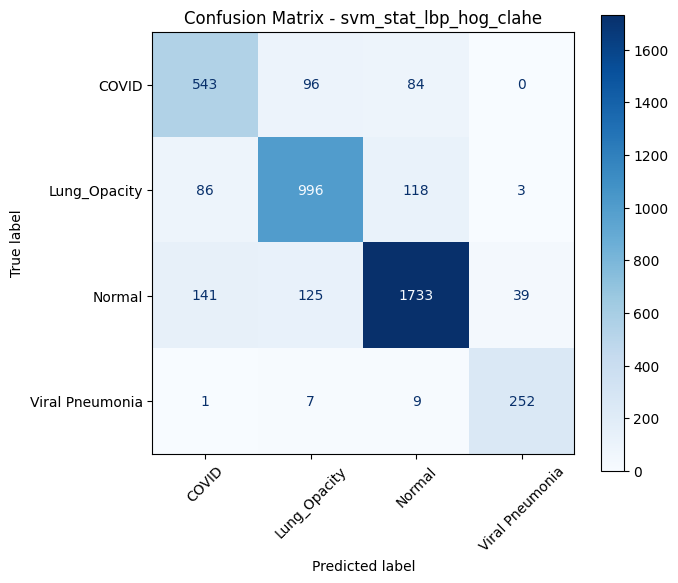


Rapport de classification pour le modèle svm_stat_lbp_hog_clahe:

                 precision    recall  f1-score   support

          COVID       0.70      0.75      0.73       723
   Lung_Opacity       0.81      0.83      0.82      1203
         Normal       0.89      0.85      0.87      2038
Viral Pneumonia       0.86      0.94      0.90       269

       accuracy                           0.83      4233
      macro avg       0.82      0.84      0.83      4233
   weighted avg       0.84      0.83      0.83      4233



In [28]:
model_name = "svm_stat_lbp_hog_clahe"
plot_confusion_matrix(model_name)
print_classification_report(model_name)
# plot_feature_importance(model_name)

### K-NEAREST NEIGHBORS (KNN)

In [12]:
def train_knn(X_train, y_train):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            # n_neighbors=5,
            # weights="distance",
            # metric="euclidean",
            # n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    return model

MODEL_DIR = "../models/k_nearest_neighbors"
os.makedirs(MODEL_DIR, exist_ok=True)

results = []
trained_models = {}

for name, df in datasets.items():

    t0 = time()
    
    X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df)

    model = train_knn(X_train, y_train)
    joblib.dump(model, MODEL_DIR + f"/knn_{name.lower()}.pkl")
    
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
       
    print(f"KNN - {name} - F1 macro: {round(100*f1_macro, 1)}% - {round(time()-t0, 1)}s")

    results.append({
        "dataset": name,
        "n_features": X_train.shape[1],
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })

df_results = pd.DataFrame(results)
df_results.to_csv(MODEL_DIR + f"/knn_results.csv", index=False)

display(
    df_results.sort_values("f1_macro", ascending=False)
)

KNN - STAT_CLAHE - F1 macro: 69.4% - 0.7s
KNN - LBP_CLAHE - F1 macro: 60.6% - 2.5s
KNN - HOG_CLAHE - F1 macro: 68.4% - 1.3s
KNN - STAT_LBP_CLAHE - F1 macro: 74.5% - 0.2s
KNN - STAT_HOG_CLAHE - F1 macro: 70.3% - 1.4s
KNN - LBP_HOG_CLAHE - F1 macro: 69.9% - 1.7s
KNN - STAT_LBP_HOG_CLAHE - F1 macro: 71.6% - 1.7s
KNN - STAT_NO_CLAHE - F1 macro: 67.4% - 0.6s
KNN - LBP_NO_CLAHE - F1 macro: 62.3% - 0.3s
KNN - HOG_NO_CLAHE - F1 macro: 69.1% - 1.8s
KNN - STAT_LBP_NO_CLAHE - F1 macro: 73.0% - 0.2s
KNN - STAT_HOG_NO_CLAHE - F1 macro: 70.1% - 2.1s
KNN - LBP_HOG_NO_CLAHE - F1 macro: 70.8% - 3.5s
KNN - STAT_LBP_HOG_NO_CLAHE - F1 macro: 72.0% - 2.3s


,dataset,n_features,accuracy,f1_macro,f1_weighted
3,STAT_LBP_CLAHE,41,0.777935,0.745072,0.773619
10,STAT_LBP_NO_CLAHE,41,0.757619,0.729591,0.754604
13,STAT_LBP_HOG_NO_CLAHE,617,0.743208,0.720400,0.734817
6,STAT_LBP_HOG_CLAHE,617,0.742499,0.715513,0.733990
12,LBP_HOG_NO_CLAHE,602,0.733286,0.707517,0.724092
4,STAT_HOG_CLAHE,591,0.730687,0.702562,0.721460
11,STAT_HOG_NO_CLAHE,591,0.726435,0.700732,0.718070
5,LBP_HOG_CLAHE,602,0.728325,0.698757,0.718829
0,STAT_CLAHE,15,0.745807,0.693560,0.741189
9,HOG_NO_CLAHE,576,0.717222,0.690559,0.708607


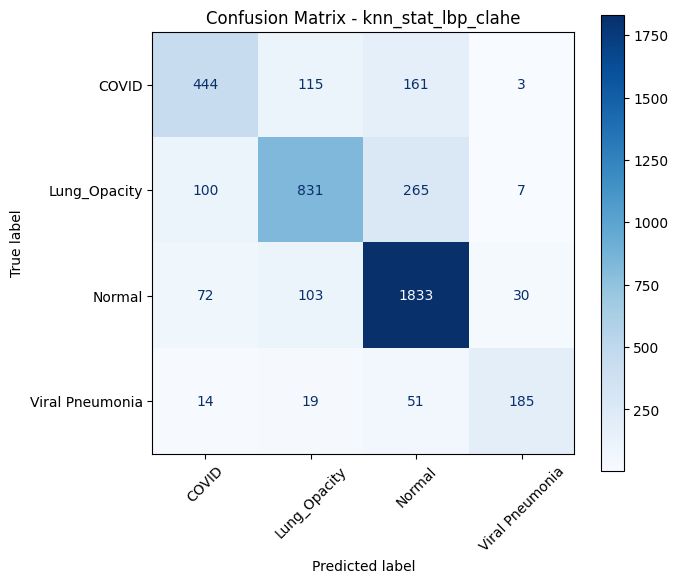


Rapport de classification pour le modèle knn_stat_lbp_clahe:

                 precision    recall  f1-score   support

          COVID       0.70      0.61      0.66       723
   Lung_Opacity       0.78      0.69      0.73      1203
         Normal       0.79      0.90      0.84      2038
Viral Pneumonia       0.82      0.69      0.75       269

       accuracy                           0.78      4233
      macro avg       0.77      0.72      0.75      4233
   weighted avg       0.78      0.78      0.77      4233



In [13]:
model_name = "knn_stat_lbp_clahe"
plot_confusion_matrix(model_name)
print_classification_report(model_name)
# plot_feature_importance(model_name)

### RANDOM FOREST (RF)

In [ ]:
def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(
        # n_estimators=300,
        # max_depth=None,
        # class_weight="balanced",
        random_state=SEED,
        # n_jobs=-1
    )

    model.fit(X_train, y_train)

    return model

MODEL_DIR = "../models/random_forest"
os.makedirs(MODEL_DIR, exist_ok=True)

results = []
trained_models = {}

for name, df in datasets.items():

    t0 = time()
    
    X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df)

    model = train_random_forest(X_train, y_train)
    joblib.dump(model, MODEL_DIR + f"/rf_{name.lower()}.pkl")
    
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
       
    print(f"RF - {name} - F1 macro: {round(100*f1_macro, 1)}% - {round(time()-t0, 1)}s")

    results.append({
        "dataset": name,
        "n_features": X_train.shape[1],
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })

df_results = pd.DataFrame(results)
df_results.to_csv(MODEL_DIR + f"/rf_results.csv", index=False)

display(
    df_results.sort_values("f1_macro", ascending=False)
)

RF - STAT_CLAHE - F1 macro: 71.9% - 4.3s
RF - LBP_CLAHE - F1 macro: 65.3% - 8.3s
RF - HOG_CLAHE - F1 macro: 71.5% - 41.7s
RF - STAT_LBP_CLAHE - F1 macro: 78.3% - 10.0s
RF - STAT_HOG_CLAHE - F1 macro: 77.2% - 42.8s
RF - LBP_HOG_CLAHE - F1 macro: 74.7% - 42.9s
RF - STAT_LBP_HOG_CLAHE - F1 macro: 79.2% - 45.9s
RF - STAT_NO_CLAHE - F1 macro: 71.3% - 5.2s
RF - LBP_NO_CLAHE - F1 macro: 66.1% - 9.5s
RF - HOG_NO_CLAHE - F1 macro: 72.8% - 43.4s
RF - STAT_LBP_NO_CLAHE - F1 macro: 76.9% - 10.4s
RF - STAT_HOG_NO_CLAHE - F1 macro: 76.7% - 43.3s
RF - LBP_HOG_NO_CLAHE - F1 macro: 75.8% - 46.1s
RF - STAT_LBP_HOG_NO_CLAHE - F1 macro: 78.9% - 45.8s


,dataset,n_features,accuracy,f1_macro,f1_weighted
6,STAT_LBP_HOG_CLAHE,617,0.813371,0.791789,0.807521
13,STAT_LBP_HOG_NO_CLAHE,617,0.805811,0.788860,0.800234
3,STAT_LBP_CLAHE,41,0.810064,0.783024,0.806133
4,STAT_HOG_CLAHE,591,0.799197,0.772335,0.791347
10,STAT_LBP_NO_CLAHE,41,0.794708,0.769187,0.791200
11,STAT_HOG_NO_CLAHE,591,0.788802,0.766710,0.782153
12,LBP_HOG_NO_CLAHE,602,0.785495,0.758176,0.776142
5,LBP_HOG_CLAHE,602,0.781951,0.746758,0.770640
9,HOG_NO_CLAHE,576,0.763997,0.727987,0.750775
0,STAT_CLAHE,15,0.773210,0.718630,0.767534


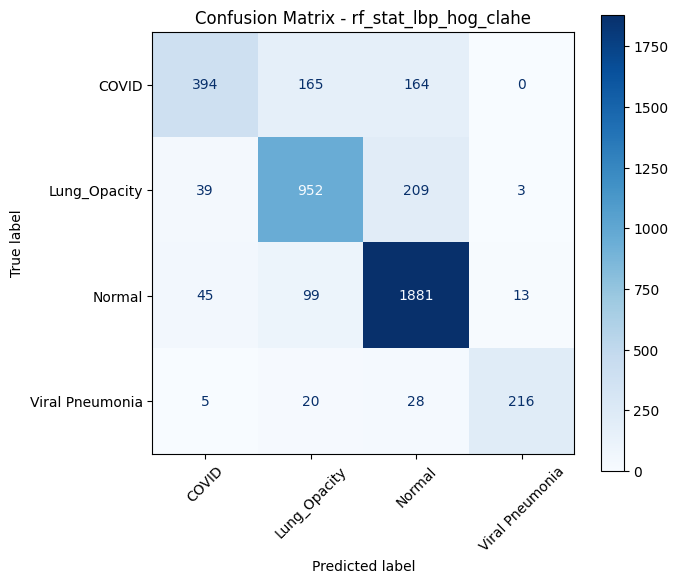


Rapport de classification pour le modèle rf_stat_lbp_hog_clahe:

                 precision    recall  f1-score   support

          COVID       0.82      0.54      0.65       723
   Lung_Opacity       0.77      0.79      0.78      1203
         Normal       0.82      0.92      0.87      2038
Viral Pneumonia       0.93      0.80      0.86       269

       accuracy                           0.81      4233
      macro avg       0.84      0.77      0.79      4233
   weighted avg       0.81      0.81      0.81      4233



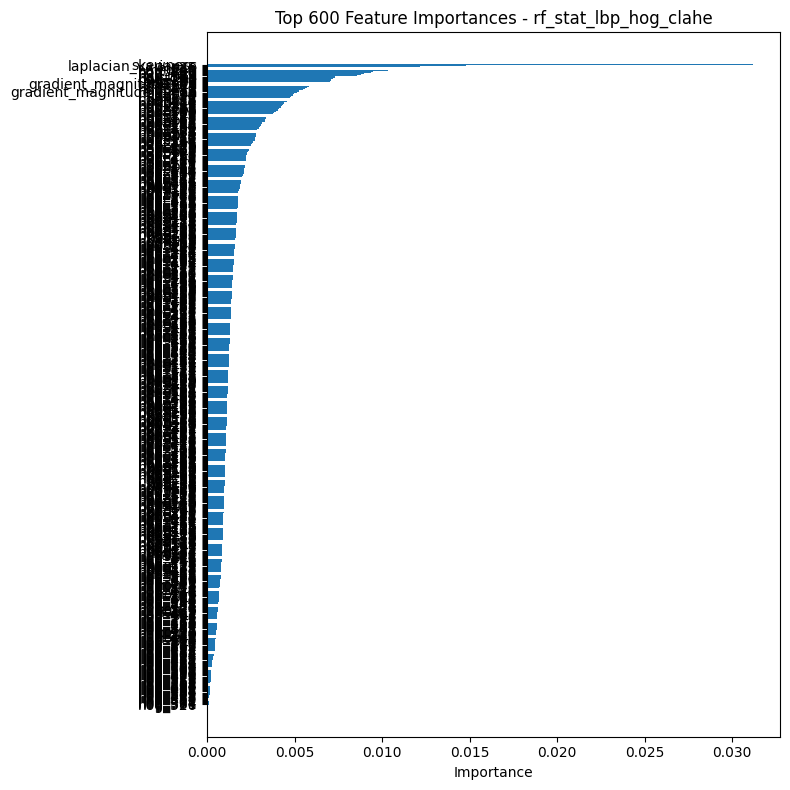

In [21]:
model_name = "rf_stat_lbp_hog_clahe"
plot_confusion_matrix(model_name)
print_classification_report(model_name)
plot_feature_importance(model_name, 600)

### XGBOOST (XGB)

In [16]:
def train_xgboost(X_train, y_train):

    model = XGBClassifier(
        # n_estimators=300,
        # max_depth=6,
        # learning_rate=0.1,
        # subsample=0.8,
        # colsample_bytree=0.8,
        # objective="multi:softprob",
        # eval_metric="mlogloss",
        random_state=SEED,
        # n_jobs=-1
    )

    model.fit(X_train, y_train)

    return model

MODEL_DIR = "../models/xgboost"
os.makedirs(MODEL_DIR, exist_ok=True)

results = []
trained_models = {}

for name, df in datasets.items():

    t0 = time()
    
    X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df)

    model = train_xgboost(X_train, y_train)
    joblib.dump(model, MODEL_DIR + f"/xgb_{name.lower()}.pkl")
    
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
       
    print(f"XGB - {name} - F1 macro: {round(100*f1_macro, 1)}% - {round(time()-t0, 1)}s")

    results.append({
        "dataset": name,
        "n_features": X_train.shape[1],
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })

df_results = pd.DataFrame(results)
df_results.to_csv(MODEL_DIR + f"/xgb_results.csv", index=False)

display(
    df_results.sort_values("f1_macro", ascending=False)
)

XGB - STAT_CLAHE - F1 macro: 71.7% - 1.9s
XGB - LBP_CLAHE - F1 macro: 66.8% - 0.9s
XGB - HOG_CLAHE - F1 macro: 76.4% - 20.6s
XGB - STAT_LBP_CLAHE - F1 macro: 80.4% - 1.6s
XGB - STAT_HOG_CLAHE - F1 macro: 84.3% - 23.5s
XGB - LBP_HOG_CLAHE - F1 macro: 81.3% - 31.6s
XGB - STAT_LBP_HOG_CLAHE - F1 macro: 86.2% - 31.4s
XGB - STAT_NO_CLAHE - F1 macro: 71.6% - 1.2s
XGB - LBP_NO_CLAHE - F1 macro: 68.4% - 1.7s
XGB - HOG_NO_CLAHE - F1 macro: 77.7% - 30.8s
XGB - STAT_LBP_NO_CLAHE - F1 macro: 80.1% - 2.4s
XGB - STAT_HOG_NO_CLAHE - F1 macro: 83.5% - 33.2s
XGB - LBP_HOG_NO_CLAHE - F1 macro: 82.2% - 33.7s
XGB - STAT_LBP_HOG_NO_CLAHE - F1 macro: 85.2% - 37.6s


,dataset,n_features,accuracy,f1_macro,f1_weighted
6,STAT_LBP_HOG_CLAHE,617,0.864635,0.861825,0.863199
13,STAT_LBP_HOG_NO_CLAHE,617,0.856839,0.851734,0.854809
4,STAT_HOG_CLAHE,591,0.850224,0.842529,0.848234
11,STAT_HOG_NO_CLAHE,591,0.839830,0.834834,0.837984
12,LBP_HOG_NO_CLAHE,602,0.830617,0.822045,0.827665
5,LBP_HOG_CLAHE,602,0.826601,0.813496,0.822654
3,STAT_LBP_CLAHE,41,0.825656,0.804391,0.823637
10,STAT_LBP_NO_CLAHE,41,0.815970,0.800844,0.814087
9,HOG_NO_CLAHE,576,0.792582,0.777138,0.787240
2,HOG_CLAHE,576,0.788094,0.763516,0.780878


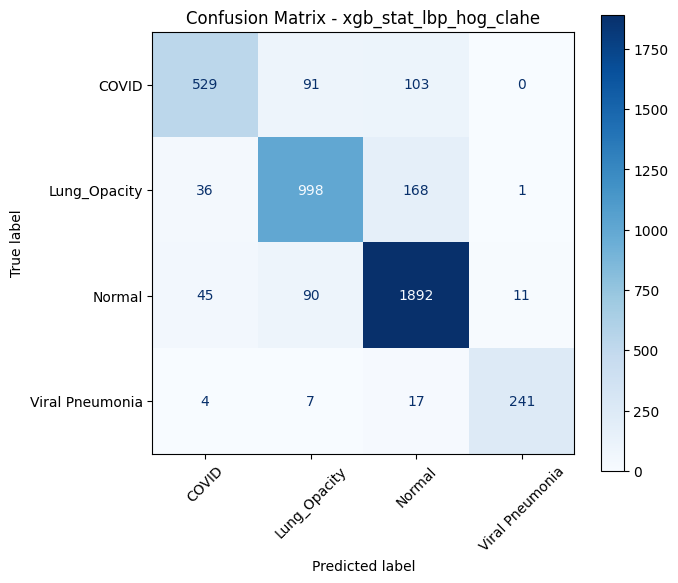


Rapport de classification pour le modèle xgb_stat_lbp_hog_clahe:

                 precision    recall  f1-score   support

          COVID       0.86      0.73      0.79       723
   Lung_Opacity       0.84      0.83      0.84      1203
         Normal       0.87      0.93      0.90      2038
Viral Pneumonia       0.95      0.90      0.92       269

       accuracy                           0.86      4233
      macro avg       0.88      0.85      0.86      4233
   weighted avg       0.86      0.86      0.86      4233



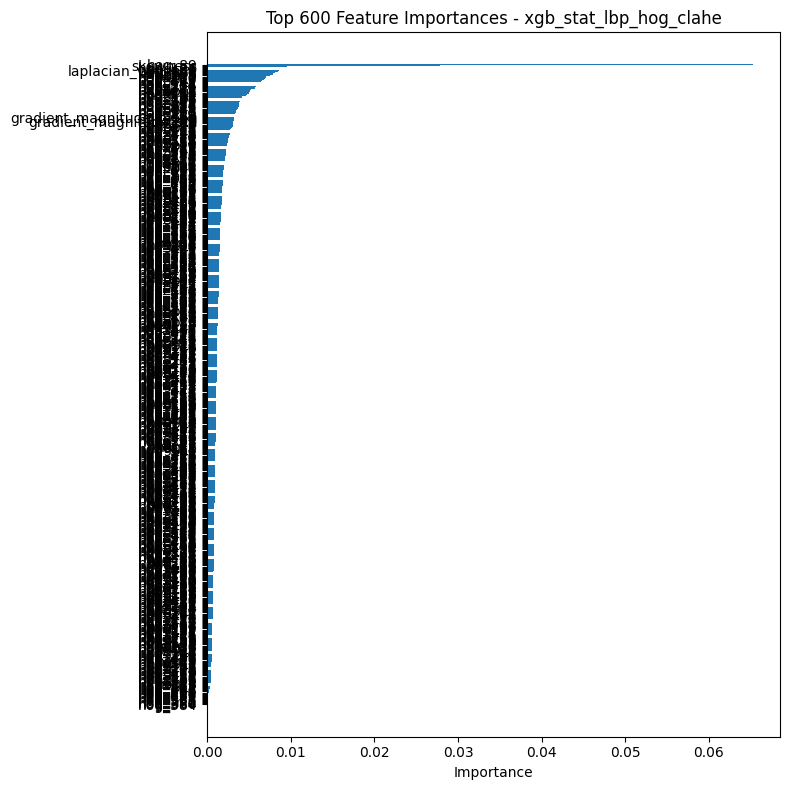

In [22]:
model_name = "xgb_stat_lbp_hog_clahe"
plot_confusion_matrix(model_name)
print_classification_report(model_name)
plot_feature_importance(model_name, 600)